In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv("expanded_5500_records.csv")
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [8]:
print(df.info())
print("-------------------------------");
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               4757 non-null   float64
 1   Hardness         5500 non-null   float64
 2   Solids           5500 non-null   float64
 3   Chloramines      5500 non-null   float64
 4   Sulfate          4354 non-null   float64
 5   Conductivity     5500 non-null   float64
 6   Organic_carbon   5500 non-null   float64
 7   Trihalomethanes  5238 non-null   float64
 8   Turbidity        5500 non-null   float64
 9   Potability       5500 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 429.8 KB
None
-------------------------------
ph                  743
Hardness              0
Solids                0
Chloramines           0
Sulfate            1146
Conductivity          0
Organic_carbon        0
Trihalomethanes     262
Turbidity             0
Potability            0
dtype: int64

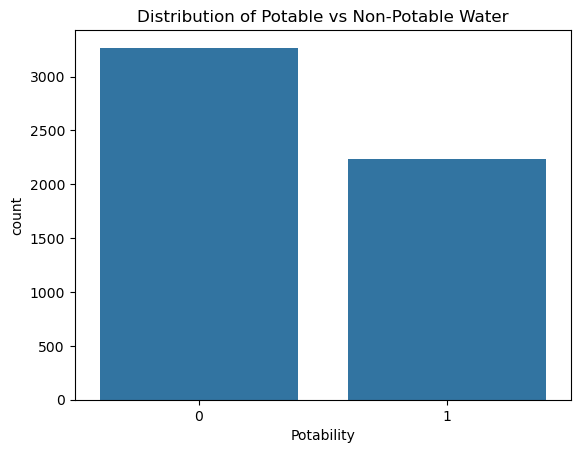

In [9]:
sns.countplot(x='Potability', data=df)
plt.title("Distribution of Potable vs Non-Potable Water")
plt.show()

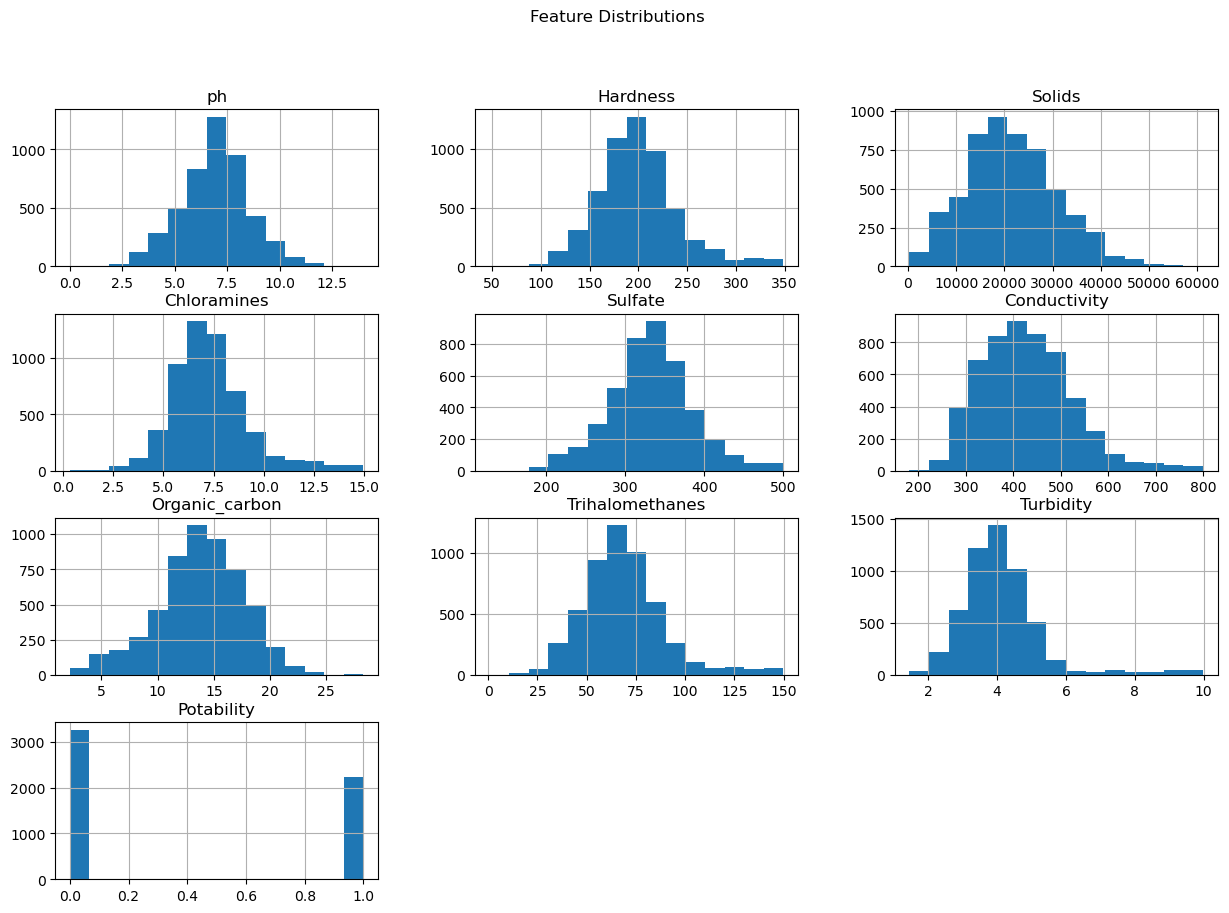

In [10]:
df.hist(bins=15, figsize=(15,10))
plt.suptitle("Feature Distributions")
plt.show()

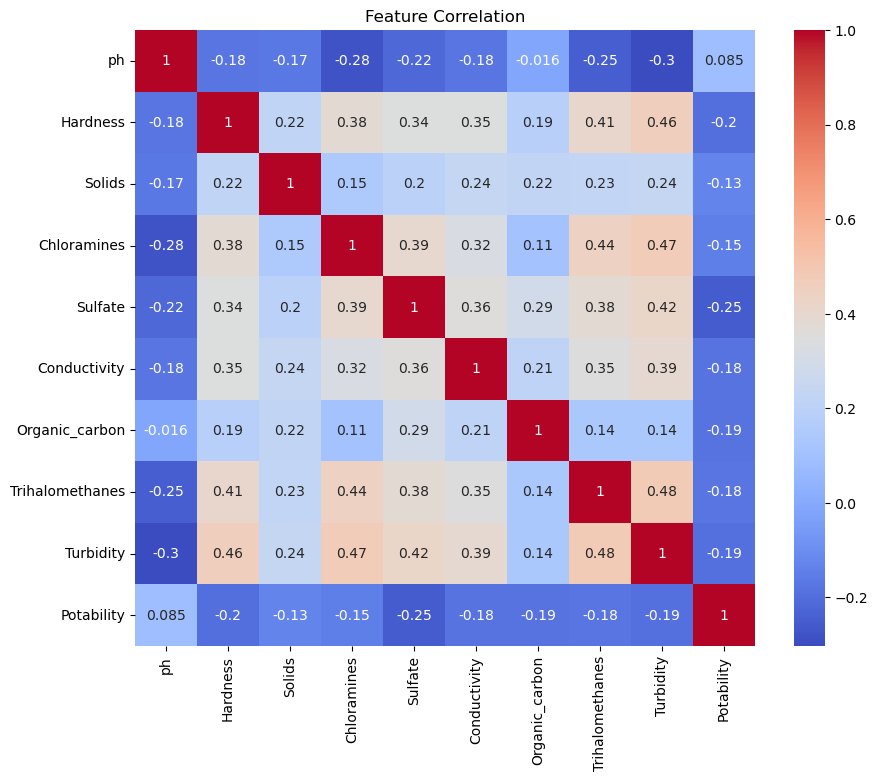

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [12]:
df.fillna(df.median(), inplace=True)


print(df.isnull().sum())

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


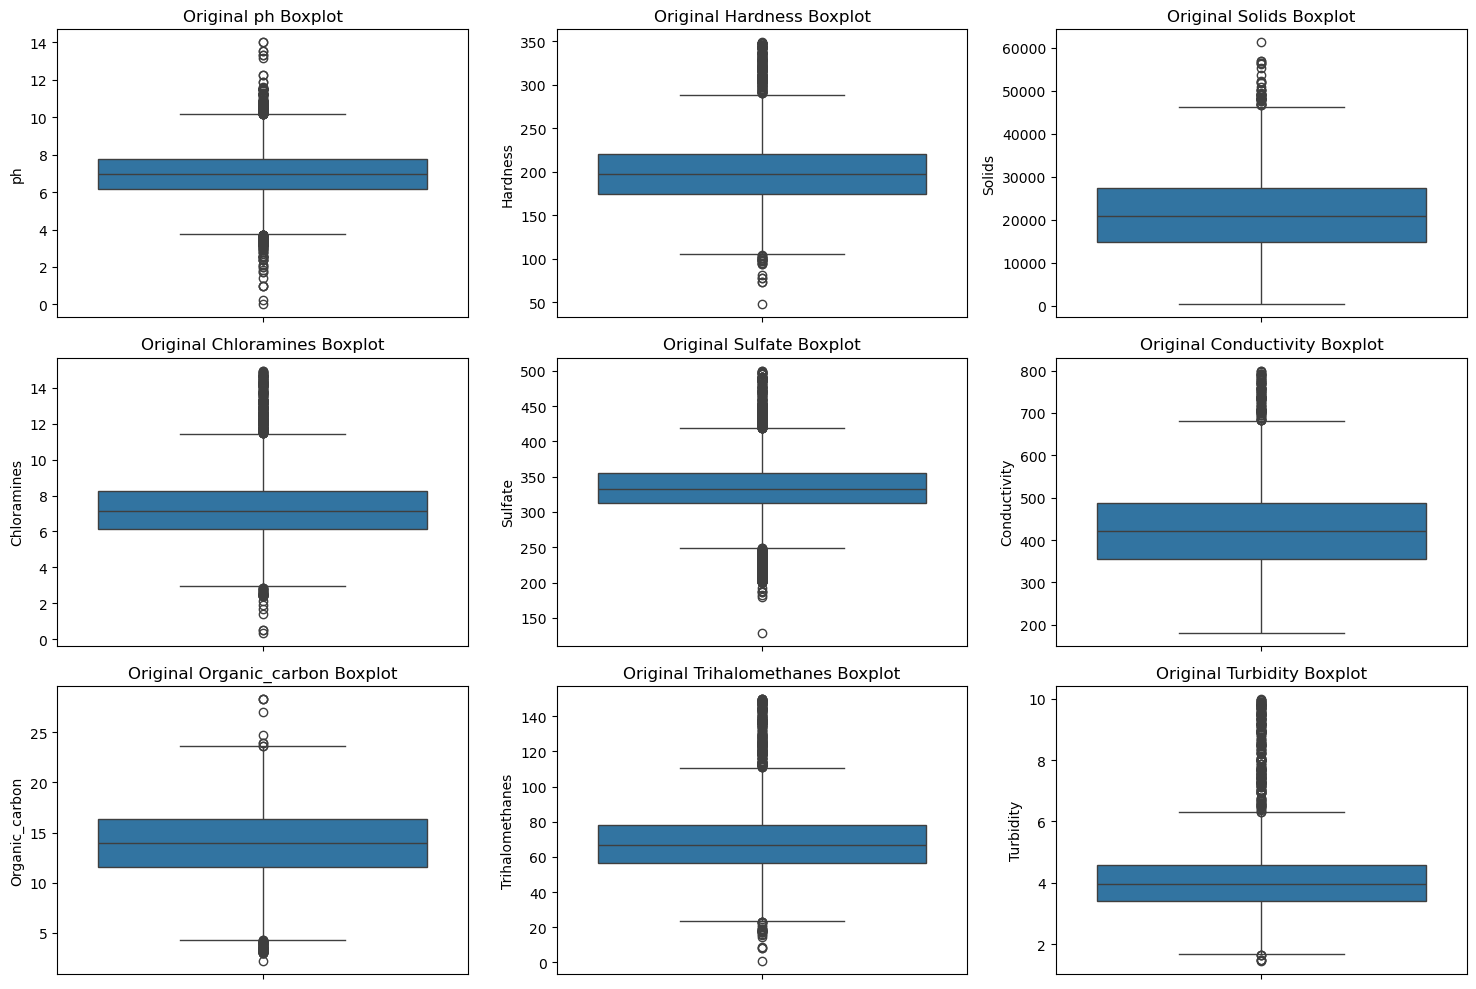

In [13]:

plt.figure(figsize=(15,10))
for i, col in enumerate(df.columns[:-1]):  # exclude target
    plt.subplot(3, 3, i+1)
    sns.boxplot(df[col])
    plt.title(f"Original {col} Boxplot")
plt.tight_layout()
plt.show()

In [14]:
df_clean = df.copy()

for col in df_clean.columns[:-1]:  
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    
print("Shape after removing outliers:", df_clean.shape)

Shape after removing outliers: (4284, 10)


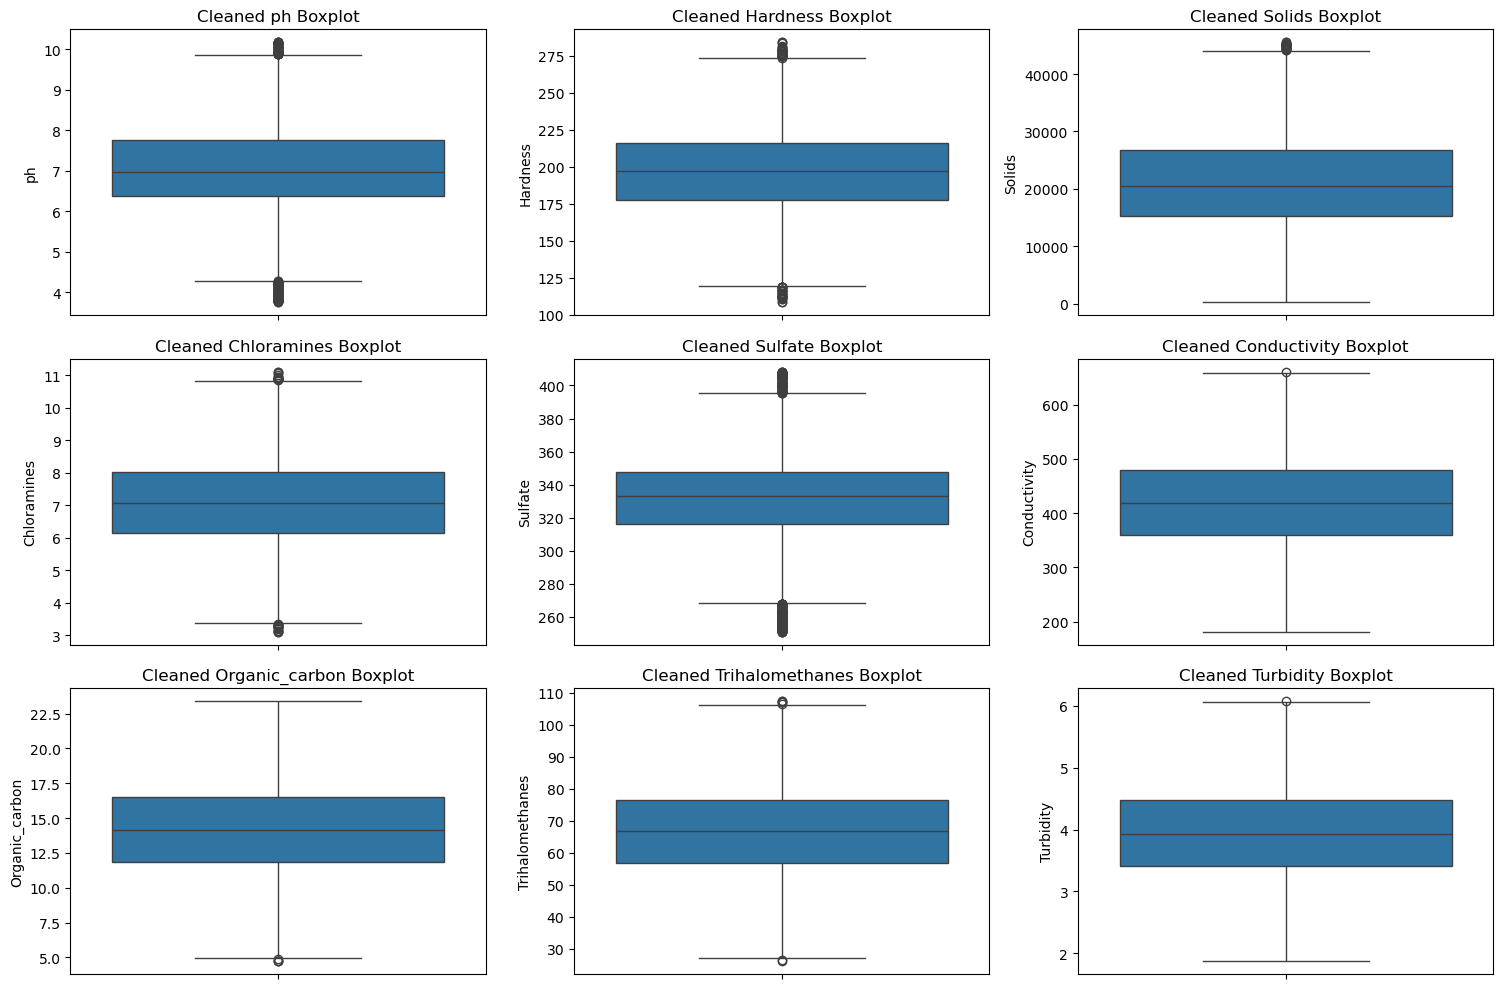

In [15]:
plt.figure(figsize=(15,10))
for i, col in enumerate(df_clean.columns[:-1]):
    plt.subplot(3, 3, i+1)
    sns.boxplot(df_clean[col])
    plt.title(f"Cleaned {col} Boxplot")
plt.tight_layout()
plt.show()

Shape after removing outliers: (4284, 10)


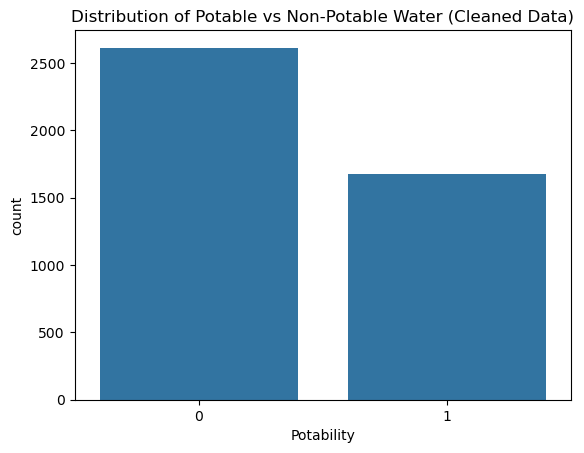

In [16]:
#delete
# df.fillna(df.mean(), inplace=True)


# print(df.isnull().sum())
# After outlier removal
print("Shape after removing outliers:", df_clean.shape)

# Check class balance after cleaning
sns.countplot(x='Potability', data=df_clean)
plt.title("Distribution of Potable vs Non-Potable Water (Cleaned Data)")
plt.show()

In [17]:

X = df_clean.drop('Potability', axis=1)
y = df_clean['Potability']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # fit on training
X_test = scaler.transform(X_test)         # transform test

In [18]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42 )
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

Accuracy: 0.8273045507584598
ROC AUC: 0.7925086729027604
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.95      0.87       523
           1       0.89      0.63      0.74       334

    accuracy                           0.83       857
   macro avg       0.85      0.79      0.81       857
weighted avg       0.84      0.83      0.82       857



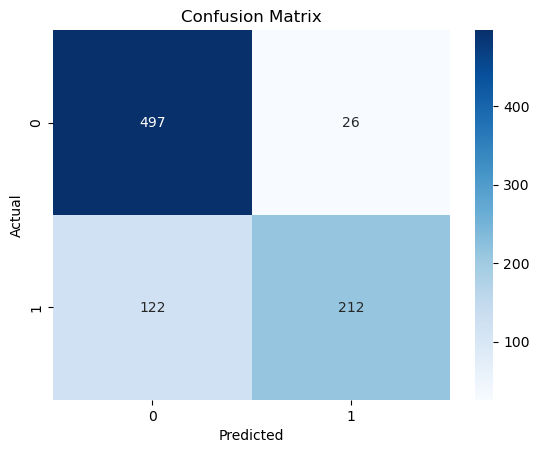

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

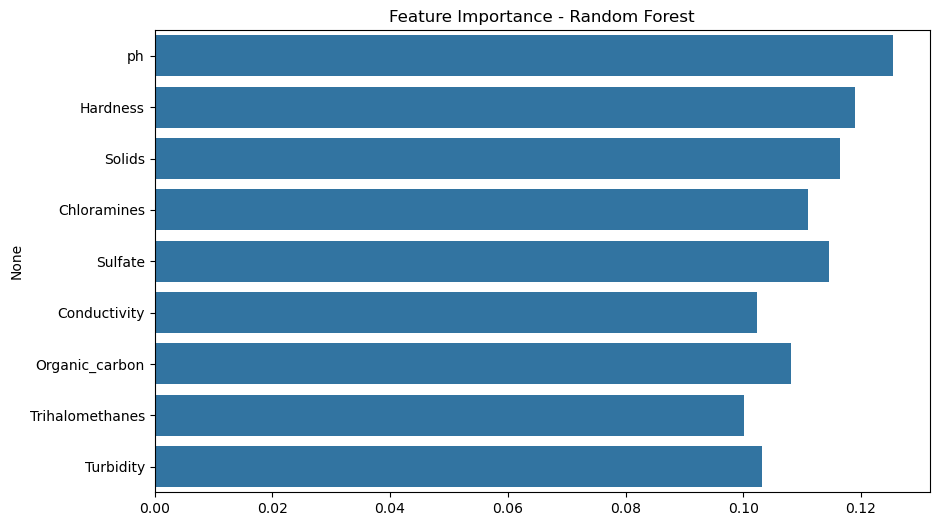

In [20]:
importances = rf.feature_importances_
features = df_clean.drop('Potability', axis=1).columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance - Random Forest")
plt.show()

In [21]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=1, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best GridSearchCV Parameters:", grid_search.best_params_)
best_rf_grid = grid_search.best_estimator_

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best GridSearchCV Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [22]:
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['auto', 'sqrt']
}

random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                   n_iter=20, cv=5, n_jobs=-1, verbose=1, scoring='accuracy', random_state=42)
random_search.fit(X_train, y_train)

print("Best RandomizedSearchCV Parameters:", random_search.best_params_)
best_rf_random = random_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RandomizedSearchCV Parameters: {'max_depth': 40, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 158}


GridSearchCV Accuracy: 0.8343057176196033
ROC AUC: 0.7998677597004843
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.96      0.88       523
           1       0.90      0.64      0.75       334

    accuracy                           0.83       857
   macro avg       0.86      0.80      0.81       857
weighted avg       0.85      0.83      0.83       857

RandomizedSearchCV Accuracy: 0.8284714119019837
ROC AUC: 0.793464695847311
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.95      0.87       523
           1       0.89      0.63      0.74       334

    accuracy                           0.83       857
   macro avg       0.85      0.79      0.81       857
weighted avg       0.84      0.83      0.82       857



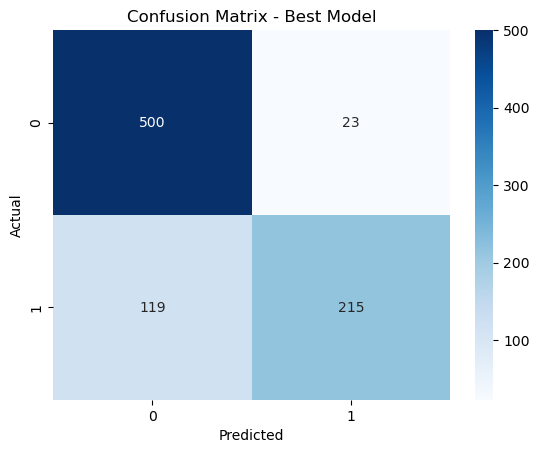

In [23]:
# GridSearchCV Model
y_pred_grid = best_rf_grid.predict(X_test)
print("GridSearchCV Accuracy:", accuracy_score(y_test, y_pred_grid))
print("ROC AUC:", roc_auc_score(y_test, y_pred_grid))
print("Classification Report:\n", classification_report(y_test, y_pred_grid))

# RandomizedSearchCV Model
y_pred_random = best_rf_random.predict(X_test)
print("RandomizedSearchCV Accuracy:", accuracy_score(y_test, y_pred_random))
print("ROC AUC:", roc_auc_score(y_test, y_pred_random))
print("Classification Report:\n", classification_report(y_test, y_pred_random))

# Confusion Matrix for Best Model (choose better accuracy)
best_model = best_rf_grid if accuracy_score(y_test, y_pred_grid) > accuracy_score(y_test, y_pred_random) else best_rf_random

cm = confusion_matrix(y_test, best_model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Best Model")
plt.show()

In [24]:


# Baseline RF accuracy
baseline_acc = accuracy_score(y_test, y_pred)

# GridSearchCV accuracy
y_pred_grid = best_rf_grid.predict(X_test)
grid_acc = accuracy_score(y_test, y_pred_grid)

# RandomizedSearchCV accuracy
y_pred_random = best_rf_random.predict(X_test)
random_acc = accuracy_score(y_test, y_pred_random)

print("Baseline RF Accuracy:", baseline_acc)
print("GridSearchCV Accuracy:", grid_acc)
print("RandomizedSearchCV Accuracy:", random_acc)

Baseline RF Accuracy: 0.8273045507584598
GridSearchCV Accuracy: 0.8343057176196033
RandomizedSearchCV Accuracy: 0.8284714119019837


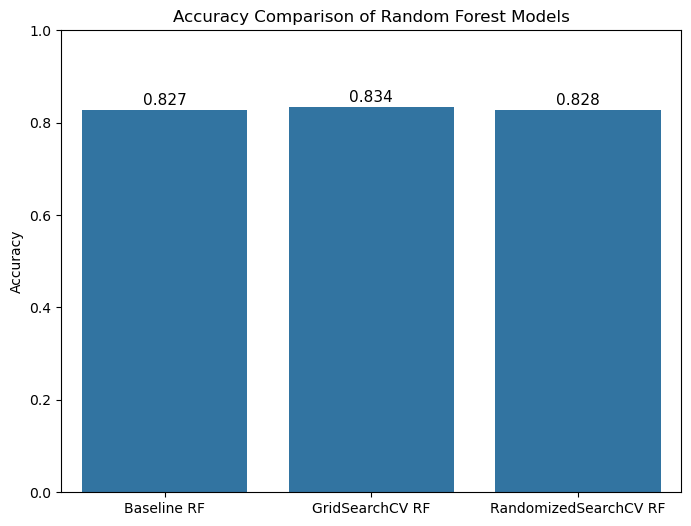

In [25]:

models = ['Baseline RF', 'GridSearchCV RF', 'RandomizedSearchCV RF']
accuracies = [baseline_acc, grid_acc, random_acc]

plt.figure(figsize=(8,6))
sns.barplot(x=models, y=accuracies)

plt.title("Accuracy Comparison of Random Forest Models")
plt.ylabel("Accuracy")
plt.ylim(0,1)


for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=11)

plt.show()

In [26]:
import pickle
pickle.dump(best_model, open("water_potability_best_rf.pkl", "wb"))

In [27]:
# Example: predict on new data


# Arrange input in correct order
new_data = np.array([[6.45,210,22500,7.9,340.1,510.3,14.5,82.1,4.6]])

# Scale input
new_data_scaled = scaler.transform(new_data)

# Predict
prediction = best_model.predict(new_data_scaled)

# Output
if prediction[0] == 1:
    print("Safe")
else:
    print("Not Safe")

    # Predict
prediction = best_model.predict(new_data_scaled)
proba = best_model.predict_proba(new_data_scaled)

print("Probability Not Safe:", proba[0][0])
print("Probability Safe:", proba[0][1])

if prediction[0] == 1:
    print("Safe")
else:
    print("Not Safe")

Not Safe
Probability Not Safe: 0.66
Probability Safe: 0.34
Not Safe


In [28]:
# Example: predict on new data
new_data = np.array([[6.45,210,22500,7.9,340.1,510.3,14.5,82.1,4.6]])  # example values

new_data_scaled = scaler.transform(new_data)

prediction = best_model.predict(new_data_scaled)

if prediction[0] == 1:
    print("Safe")
else:
    print("Not Safe")

Not Safe


In [29]:
import pickle
pickle.dump(scaler, open("scaler.pkl","wb"))

In [30]:
print("Train Accuracy:", best_model.score(X_train, y_train))
print("Test Accuracy:", best_model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.8343057176196033


In [31]:
import numpy as np

pred = best_model.predict(X_test)
print(np.unique(pred, return_counts=True))

(array([0, 1]), array([619, 238]))


In [32]:
# Example new water data
new_data = np.array([[0,0,0,0,0,0,0,0,0]])   # example values

# Clip values to original feature ranges (optional)
new_data_clipped = np.clip(new_data, X.min().values, X.max().values)

# Scale the data using the trained scaler
new_data_scaled = scaler.transform(new_data_clipped)

# Predict
prediction = best_model.predict(new_data_scaled)
proba = best_model.predict_proba(new_data_scaled)
  
# Output probabilities
print("Probability Not Safe:", proba[0][0])
print("Probability Safe:", proba[0][1])

# Output final prediction
if prediction[0] == 1:
    print("Safe")
else:
    print("Not Safe")

Probability Not Safe: 0.33
Probability Safe: 0.67
Safe


In [33]:
from sklearn.metrics import roc_curve

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold:", optimal_threshold)

Optimal Threshold: 0.36333333333333334


In [34]:
# Example new water data
new_data = np.array([[7.2, 210, 21000, 7.8, 320, 450, 15, 80, 4.5]])

# Clip values to training feature ranges
new_data_clipped = np.clip(new_data, X.min().values, X.max().values)

# Scale using trained scaler
new_data_scaled = scaler.transform(new_data_clipped)

# Get probabilities
proba = best_model.predict_proba(new_data_scaled)

# Optimal threshold
optimal_threshold = 0.36333333333333334

prob_safe = proba[0][1]   # probability of class 1 (Safe)

print("Probability Not Safe:", proba[0][0])
print("Probability Safe:", prob_safe)

# Apply custom threshold
if prob_safe >= optimal_threshold:
    print("Safe")
else:
    print("Not Safe")

Probability Not Safe: 0.56
Probability Safe: 0.44
Safe
